In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Tổng số mẫu thô: 815
Số mẫu GT hợp lệ (Chuẩn biển VN): 773

--- KẾT QUẢ ĐÁNH GIÁ CHUẨN CÔNG NGHIỆP ---
1. String Accuracy (Exact Match): 0.5084 (50.84%)
2. Mean NED (Normalized Edit Distance): 0.8612 (86.12%)
3. Format Compliance Rate: 0.4774 (47.74%)
4. Expected Calibration Error (ECE): 0.4237 (Càng thấp càng tốt)

[INFO] Đã lưu biểu đồ chất lượng cao: industrial_evaluation_report.png


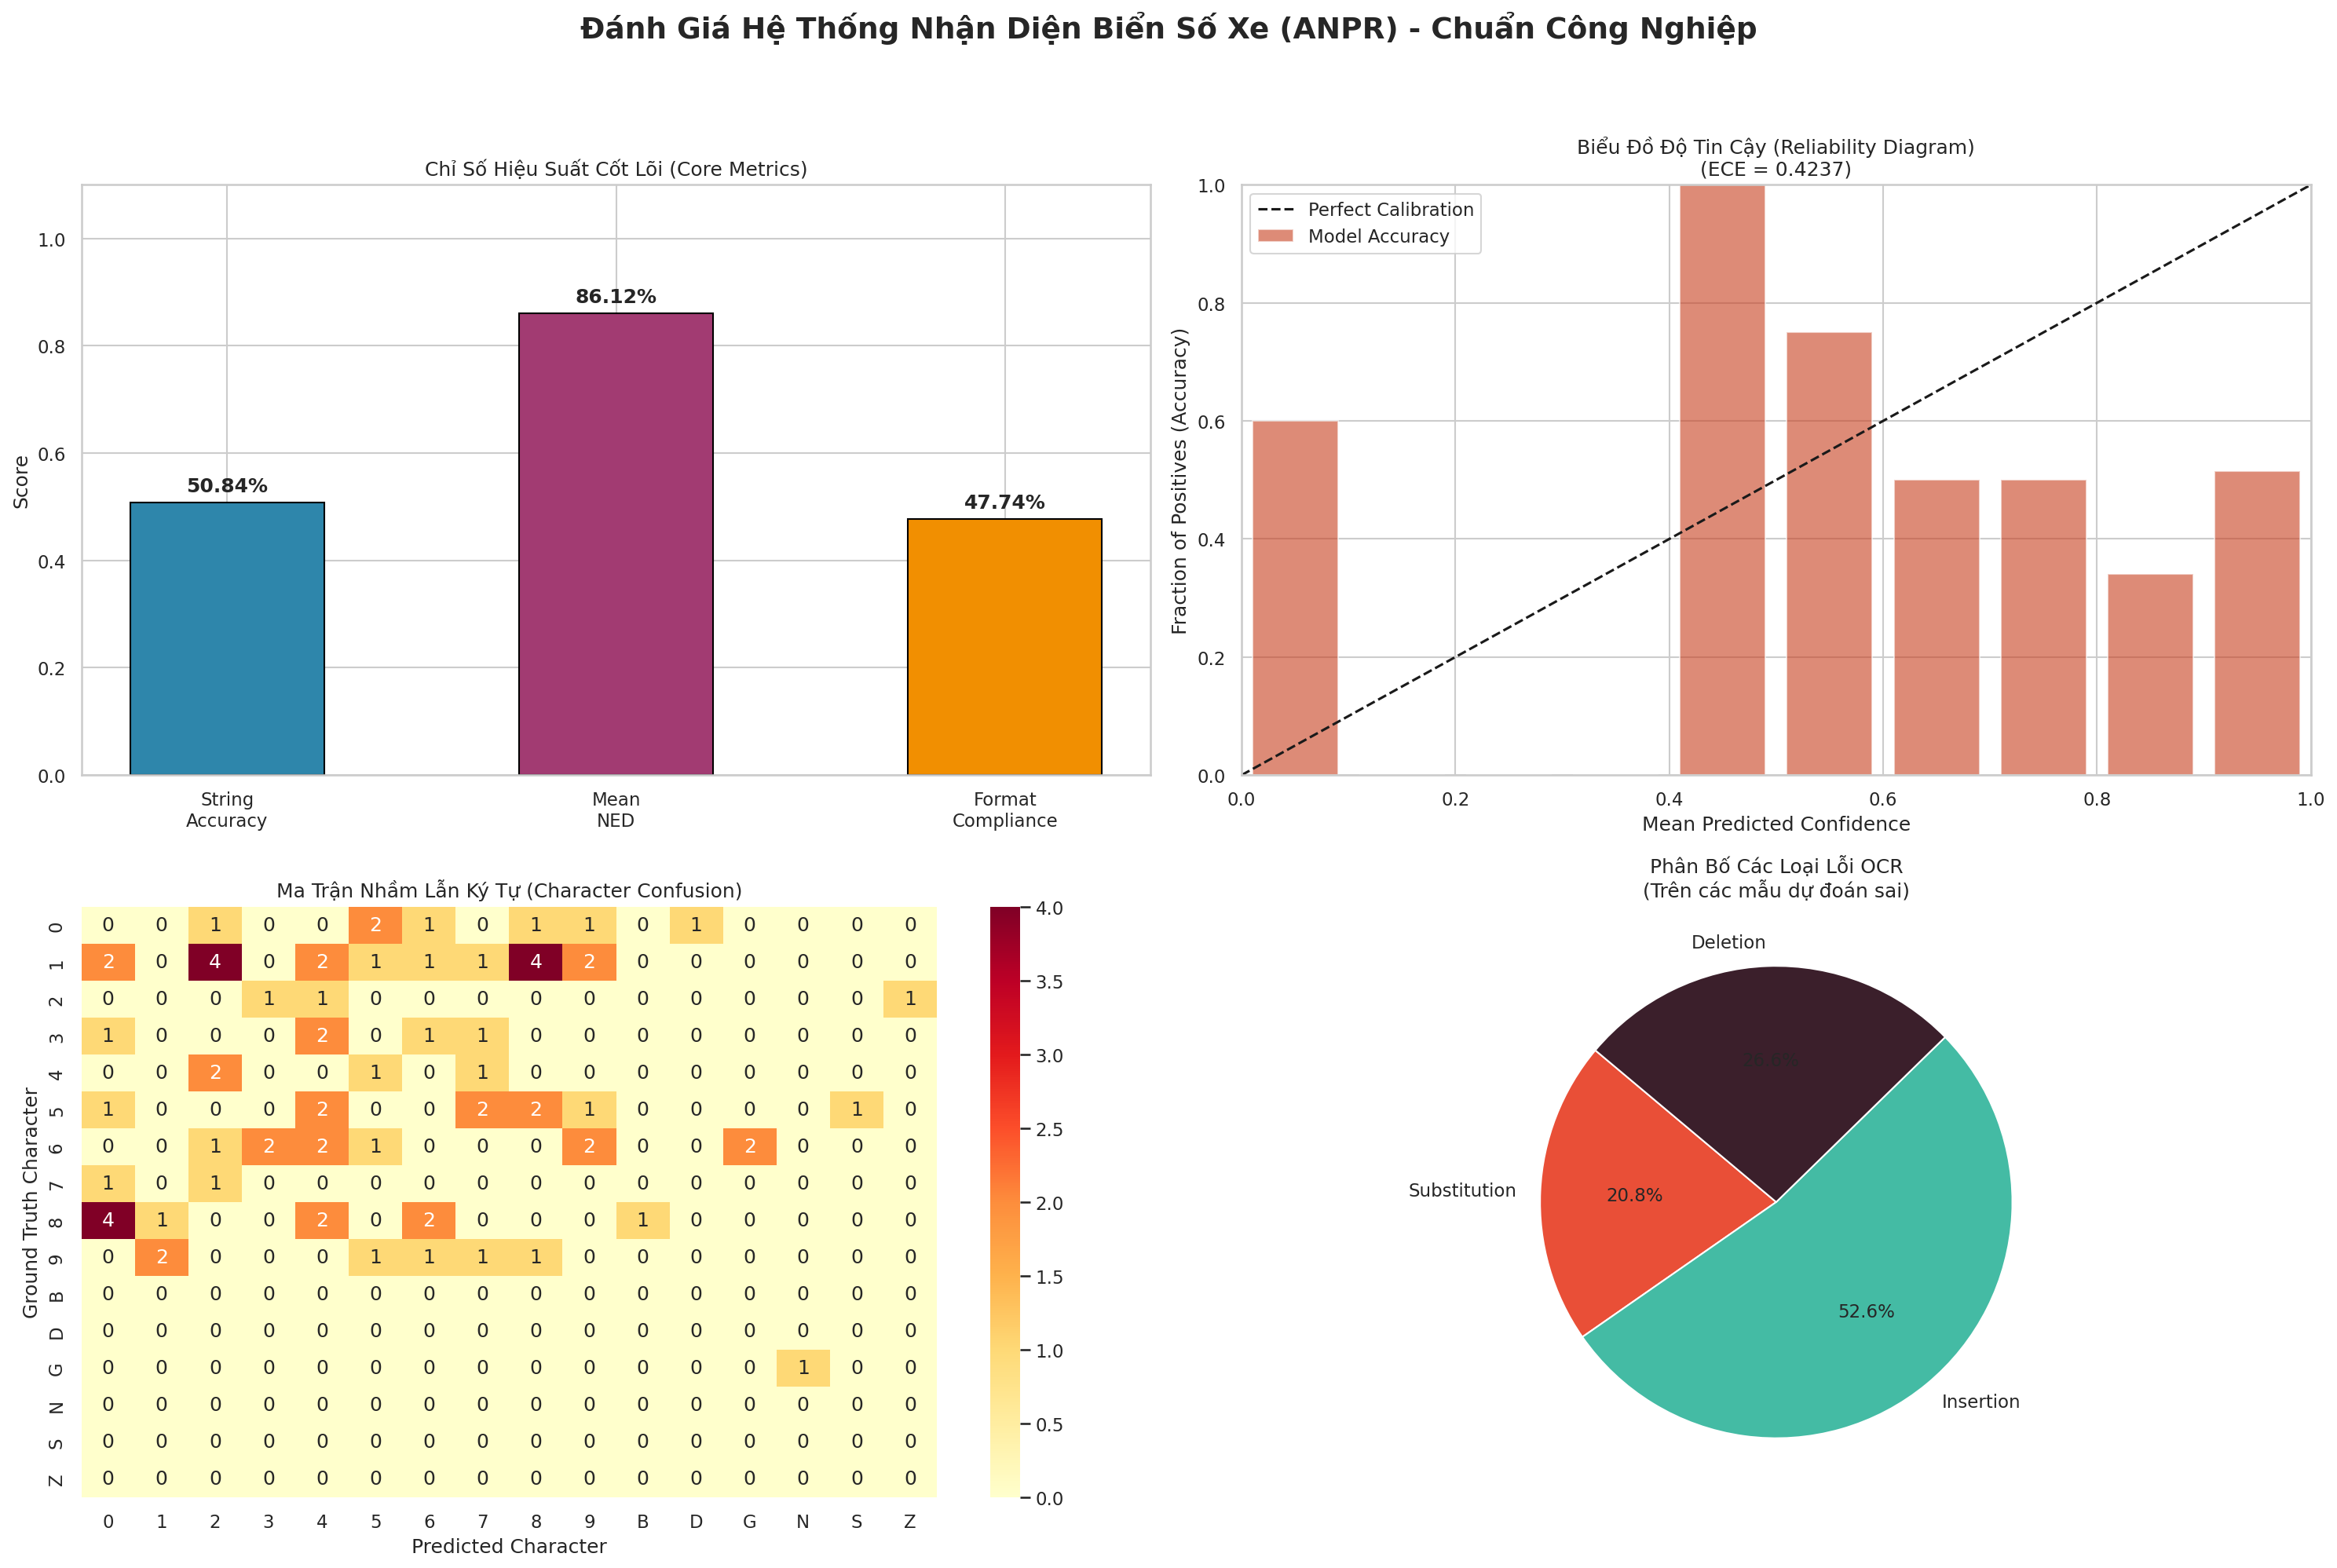

[INFO] Đã xuất file CSV và JSON báo cáo.


In [5]:
import pandas as pd
import numpy as np
import re
import ast
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. THIẾT LẬP & HÀM HỖ TRỢ (SETUP & HELPERS)
# ==========================================
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150
})
sns.set_theme(style="whitegrid", palette="muted")

def parse_plate_list(val):
    """Trích xuất danh sách biển số từ chuỗi CSV bị lỗi định dạng"""
    if pd.isna(val) or str(val).strip() in ['[]', 'nan', '']:
        return []
    try:
        cleaned = str(val).replace('""', '"')
        parsed = ast.literal_eval(cleaned)
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except:
        match = re.findall(r'"([^"]+)"', str(val))
        return match if match else []

def is_valid_vn_plate(plate_str):
    """Lọc Ground Truth theo chuẩn tổng quát của biển số Việt Nam"""
    if not plate_str or len(plate_str) < 6 or len(plate_str) > 12:
        return False
    # Loại bỏ các text nhiễu như KAMAZ, VN12121, FOLD0611
    if re.match(r'^[A-Z]{3,}$', plate_str) or re.match(r'^[0-9]{7,}$', plate_str):
        return False
    # Chấp nhận cấu trúc cơ bản: Có ít nhất 2 số và 1 chữ cái
    has_digits = bool(re.search(r'\d', plate_str))
    has_letters = bool(re.search(r'[A-Z]', plate_str))
    return has_digits and has_letters

def normalize_plate(text):
    """Chuẩn hóa biển số: Loại bỏ dấu câu, khoảng trắng, đồng nhất về chữ hoa"""
    text = str(text).upper()
    # Thay thế các dấu phân cách phổ biến thành '-'
    text = re.sub(r'[\.·\s]', '-', text)
    # Loại bỏ các ký tự đặc biệt không mong muốn
    text = re.sub(r'[^A-Z0-9\-]', '', text)
    return text

def levenshtein_distance(s1, s2):
    """Tính khoảng cách Levenshtein"""
    if len(s1) < len(s2): return levenshtein_distance(s2, s1)
    if len(s2) == 0: return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

def compute_ece(confidences, accuracies, n_bins=10):
    """Tính Expected Calibration Error (ECE) - Metric chuẩn công nghiệp"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            avg_confidence = np.mean(confidences[in_bin])
            avg_accuracy = np.mean(accuracies[in_bin])
            ece += np.abs(avg_accuracy - avg_confidence) * prop_in_bin
    return ece

# ==========================================
# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU (DATA LOADING)
# ==========================================
df0 = pd.read_csv('shard-0_aggregated_results.csv')
df1 = pd.read_csv('shard-1_aggregated_results.csv')
df = pd.concat([df0, df1], ignore_index=True)

# Trích xuất biển số chính (Primary Plate)
df['gt_list'] = df['plate_text'].apply(parse_plate_list)
df['pred_list'] = df['raw_plate_text'].apply(parse_plate_list)

df['gt_text'] = df['gt_list'].apply(lambda x: x[0] if x else None)
df['pred_text'] = df['pred_list'].apply(lambda x: x[0] if x else None)

# Lọc bỏ các bản ghi không có GT hoặc GT không phải biển số chuẩn
df = df[df['gt_text'].notna()].copy()
df['is_valid_gt'] = df['gt_text'].apply(is_valid_vn_plate)
df_eval = df[df['is_valid_gt']].copy()

print(f"Tổng số mẫu thô: {len(df)}")
print(f"Số mẫu GT hợp lệ (Chuẩn biển VN): {len(df_eval)}")

# ==========================================
# 3. TÍNH TOÁN METRIC CÔNG NGHIỆP (INDUSTRIAL METRICS)
# ==========================================
df_eval['gt_norm'] = df_eval['gt_text'].apply(normalize_plate)
df_eval['pred_norm'] = df_eval['pred_text'].apply(normalize_plate)

# Metric 1: String Accuracy (Exact Match trên chuỗi đã chuẩn hóa)
df_eval['is_exact_match'] = df_eval['gt_norm'] == df_eval['pred_norm']
string_accuracy = df_eval['is_exact_match'].mean()

# Metric 2: Normalized Edit Distance (NED)
df_eval['lev_dist'] = df_eval.apply(lambda r: levenshtein_distance(r['gt_norm'], r['pred_norm']), axis=1)
df_eval['max_len'] = df_eval.apply(lambda r: max(len(r['gt_norm']), len(r['pred_norm']), 1), axis=1)
df_eval['ned'] = 1 - (df_eval['lev_dist'] / df_eval['max_len'])
mean_ned = df_eval['ned'].mean()

# Metric 3: Format Compliance Rate (Tỷ lệ dự đoán đúng format)
pattern_vn = r"^\d{2}[A-Z]{1,2}-\d{3,5}-?\d{2}$|^\d{2}-[A-Z]?\d{5,6}$"
df_eval['is_valid_format'] = df_eval['pred_norm'].apply(lambda x: bool(re.match(pattern_vn, x)))
format_compliance = df_eval['is_valid_format'].mean()

# Metric 4: Expected Calibration Error (ECE)
ece_score = compute_ece(df_eval['max_confidence'].values, df_eval['is_exact_match'].values)

print("\n--- KẾT QUẢ ĐÁNH GIÁ CHUẨN CÔNG NGHIỆP ---")
print(f"1. String Accuracy (Exact Match): {string_accuracy:.4f} ({string_accuracy*100:.2f}%)")
print(f"2. Mean NED (Normalized Edit Distance): {mean_ned:.4f} ({mean_ned*100:.2f}%)")
print(f"3. Format Compliance Rate: {format_compliance:.4f} ({format_compliance*100:.2f}%)")
print(f"4. Expected Calibration Error (ECE): {ece_score:.4f} (Càng thấp càng tốt)")

# ==========================================
# 4. PHÂN TÍCH LỖI CHUYÊN SÂU (DEEP ERROR ANALYSIS)
# ==========================================
# 4.1. Character Confusion Matrix (Ma trận nhầm lẫn ký tự)
substitution_pairs = []
for _, row in df_eval.iterrows():
    if row['gt_norm'] != row['pred_norm'] and len(row['gt_norm']) == len(row['pred_norm']):
        for c_gt, c_pred in zip(row['gt_norm'], row['pred_norm']):
            if c_gt != c_pred and c_gt != '-' and c_pred != '-':
                substitution_pairs.append((c_gt, c_pred))

# 4.2. Error Types Distribution
error_types = {'Substitution': 0, 'Insertion': 0, 'Deletion': 0}
for _, row in df_eval.iterrows():
    if row['gt_norm'] != row['pred_norm']:
        if len(row['gt_norm']) == len(row['pred_norm']): error_types['Substitution'] += 1
        elif len(row['gt_norm']) > len(row['pred_norm']): error_types['Deletion'] += 1
        else: error_types['Insertion'] += 1

# ==========================================
# 5. TRỰC QUAN HÓA (PROFESSIONAL VISUALIZATION)
# ==========================================
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Đánh Giá Hệ Thống Nhận Diện Biển Số Xe (ANPR) - Chuẩn Công Nghiệp',
             fontsize=18, fontweight='bold', y=0.98)

# Plot 1: Core Metrics Dashboard
ax1 = plt.subplot(2, 2, 1)
metrics = ['String\nAccuracy', 'Mean\nNED', 'Format\nCompliance']
values = [string_accuracy, mean_ned, format_compliance]
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax1.bar(metrics, values, color=colors, edgecolor='black', width=0.5)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Score')
ax1.set_title('Chỉ Số Hiệu Suất Cốt Lõi (Core Metrics)')
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2%}', ha='center', fontweight='bold')

# Plot 2: Reliability Diagram (Confidence Calibration) - Rất quan trọng trong công nghiệp
ax2 = plt.subplot(2, 2, 2)
bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_acc = []
bin_conf = []
for i in range(len(bins)-1):
    mask = (df_eval['max_confidence'] >= bins[i]) & (df_eval['max_confidence'] < bins[i+1])
    if mask.sum() > 0:
        bin_acc.append(df_eval.loc[mask, 'is_exact_match'].mean())
        bin_conf.append(df_eval.loc[mask, 'max_confidence'].mean())
    else:
        bin_acc.append(0)
        bin_conf.append(bin_centers[i])

ax2.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
ax2.bar(bin_centers, bin_acc, width=0.08, alpha=0.6, color='#C73E1D', label='Model Accuracy')
ax2.set_xlabel('Mean Predicted Confidence')
ax2.set_ylabel('Fraction of Positives (Accuracy)')
ax2.set_title(f'Biểu Đồ Độ Tin Cậy (Reliability Diagram)\n(ECE = {ece_score:.4f})')
ax2.legend()
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

# Plot 3: Character Confusion Matrix Heatmap
ax3 = plt.subplot(2, 2, 3)
if substitution_pairs:
    gt_chars, pred_chars = zip(*substitution_pairs)
    # Lấy danh sách các ký tự duy nhất và sắp xếp
    unique_chars = sorted(list(set(gt_chars + pred_chars)))
    cm = confusion_matrix(gt_chars, pred_chars, labels=unique_chars)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax3,
                xticklabels=unique_chars, yticklabels=unique_chars)
    ax3.set_xlabel('Predicted Character')
    ax3.set_ylabel('Ground Truth Character')
    ax3.set_title('Ma Trận Nhầm Lẫn Ký Tự (Character Confusion)')
else:
    ax3.text(0.5, 0.5, 'Không có lỗi thay thế ký tự', ha='center', va='center')

# Plot 4: Error Types & Confidence Distribution
ax4 = plt.subplot(2, 2, 4)
error_labels = list(error_types.keys())
error_values = list(error_types.values())
ax4.pie(error_values, labels=error_labels, autopct='%1.1f%%', startangle=140,
        colors=['#E94F37', '#44BBA4', '#3B1F2B'], textprops={'fontsize': 11})
ax4.set_title('Phân Bố Các Loại Lỗi OCR\n(Trên các mẫu dự đoán sai)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('industrial_evaluation_report.png', dpi=300, bbox_inches='tight')
print("\n[INFO] Đã lưu biểu đồ chất lượng cao: industrial_evaluation_report.png")
plt.show()

# ==========================================
# 6. XUẤT FILE DỮ LIỆU (EXPORT)
# ==========================================
# Export CSV chi tiết
export_cols = ['image', 'gt_text', 'pred_text', 'gt_norm', 'pred_norm',
               'max_confidence', 'is_exact_match', 'ned', 'is_valid_format']
df_eval[export_cols].to_csv('detailed_evaluation_results.csv', index=False, encoding='utf-8-sig')

# Export JSON báo cáo
report = {
    "industrial_metrics": {
        "string_accuracy": round(string_accuracy, 4),
        "mean_ned": round(mean_ned, 4),
        "format_compliance_rate": round(format_compliance, 4),
        "expected_calibration_error_ece": round(ece_score, 4)
    },
    "error_analysis": {
        "total_errors": sum(error_types.values()),
        "error_distribution": error_types,
        "top_character_substitutions": Counter(substitution_pairs).most_common(10)
    }
}
with open('industrial_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=4)

print("[INFO] Đã xuất file CSV và JSON báo cáo.")